# Week 6 — ODE Solvers & Finite-Difference Methods (Capstone)

> **Numerical Methods from Scratch** · Pure NumPy + Matplotlib

The grand finale. We solve **ordinary differential equations** $\frac{d\mathbf{y}}{dt} = f(t,\mathbf{y})$ — the language of physics, biology, and engineering — and then turn to **boundary-value problems** solved by finite differences, which connects directly back to the linear solvers of Week 3.

1. **Euler's method** and local vs. global truncation error.
2. **Runge–Kutta** methods, culminating in the classic **RK4**.
3. **Adaptive step control** (RK45 / Dormand–Prince idea).
4. **Stiffness** — why explicit methods explode, and how *implicit* methods (Backward Euler) save us.
5. **Boundary-value problems** via finite differences → a linear system (Week 3 returns).

This week unifies the whole course: ODE integration uses **quadrature** (Week 5) ideas, error analysis from **Week 1**, root-finding (**Week 2**) inside implicit steps, and **linear solvers** (Week 3) for boundary-value problems.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Euler's method

The simplest scheme. Approximate the solution by following the local slope:

$$ \mathbf{y}_{n+1} = \mathbf{y}_n + h\, f(t_n, \mathbf{y}_n). $$

Its **local truncation error** per step is $\mathcal{O}(h^2)$, but errors accumulate over $\mathcal{O}(1/h)$ steps, giving a **global error** of $\mathcal{O}(h)$ — *first order*. Halving $h$ only halves the error: painfully slow.


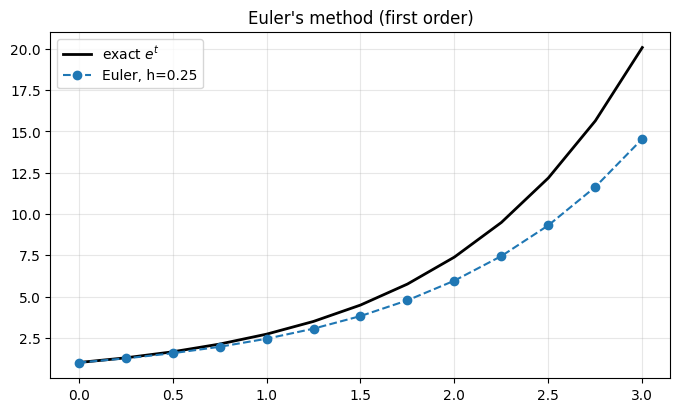

error at t=3: 5.533621694820816


In [2]:
def euler(f, t0, y0, tf, h):
    ts = np.arange(t0, tf + 0.5*h, h)
    ys = np.zeros((len(ts),) + np.shape(y0))
    ys[0] = y0
    for n in range(len(ts)-1):
        ys[n+1] = ys[n] + h * f(ts[n], ys[n])
    return ts, ys

# Test problem y' = y, y(0)=1, exact solution e^t.
f = lambda t, y: y
ts, ys = euler(f, 0, 1.0, 3.0, 0.25)
fig, ax = plt.subplots()
ax.plot(ts, np.exp(ts), "k", lw=2, label="exact $e^t$")
ax.plot(ts, ys, "o--", label="Euler, h=0.25")
ax.set_title("Euler's method (first order)"); ax.legend(); plt.show()
print("error at t=3:", abs(ys[-1] - np.exp(3)))


## 2. Runge–Kutta methods

Euler samples the slope once per step. **Runge–Kutta** methods sample it several times within the step and combine them — much like quadrature samples the integrand at several points. The classic **RK4** uses four slope evaluations:

$$
\begin{aligned}
k_1 &= f(t_n, y_n), & k_2 &= f(t_n + \tfrac h2, y_n + \tfrac h2 k_1),\\
k_3 &= f(t_n + \tfrac h2, y_n + \tfrac h2 k_2), & k_4 &= f(t_n + h, y_n + h k_3),\\
y_{n+1} &= y_n + \tfrac h6 (k_1 + 2k_2 + 2k_3 + k_4). &&
\end{aligned}
$$

It is **fourth order**: halving $h$ cuts the error by $16\times$. The accuracy-per-evaluation is vastly better than Euler.


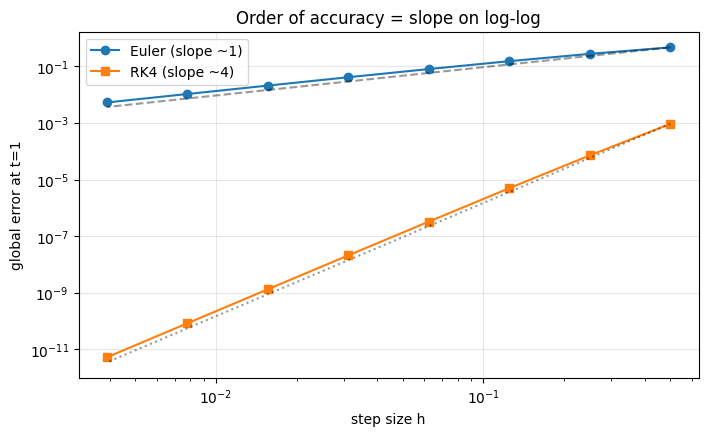

In [3]:
def rk4(f, t0, y0, tf, h):
    ts = np.arange(t0, tf + 0.5*h, h)
    ys = np.zeros((len(ts),) + np.shape(y0))
    ys[0] = y0
    for n in range(len(ts)-1):
        t, y = ts[n], ys[n]
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2 * k1)
        k3 = f(t + h/2, y + h/2 * k2)
        k4 = f(t + h, y + h * k3)
        ys[n+1] = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return ts, ys

# Convergence study: global error vs h for Euler and RK4.
hs = 0.5 ** np.arange(1, 9)
err_euler, err_rk4 = [], []
for h in hs:
    _, ye = euler(f, 0, 1.0, 1.0, h); err_euler.append(abs(ye[-1] - np.e))
    _, yr = rk4(f, 0, 1.0, 1.0, h);   err_rk4.append(abs(yr[-1] - np.e))

fig, ax = plt.subplots()
ax.loglog(hs, err_euler, "o-", label="Euler (slope ~1)")
ax.loglog(hs, err_rk4, "s-", label="RK4 (slope ~4)")
ax.loglog(hs, hs*err_euler[0]/hs[0], "k--", alpha=0.4)
ax.loglog(hs, hs**4*err_rk4[0]/hs[0]**4, "k:", alpha=0.4)
ax.set_xlabel("step size h"); ax.set_ylabel("global error at t=1")
ax.set_title("Order of accuracy = slope on log-log"); ax.legend(); plt.show()


## 3. Adaptive step-size control

A good integrator does not use a fixed $h$ — it takes large steps where the solution is smooth and small steps where it changes fast. The idea (used in RK45 / Dormand–Prince) is to compute the step at **two different orders**, use their difference as a local error estimate, and adjust $h$ to keep that estimate near a tolerance. Here is a compact embedded RK pair (Bogacki–Shampine style, orders 2 and 3).


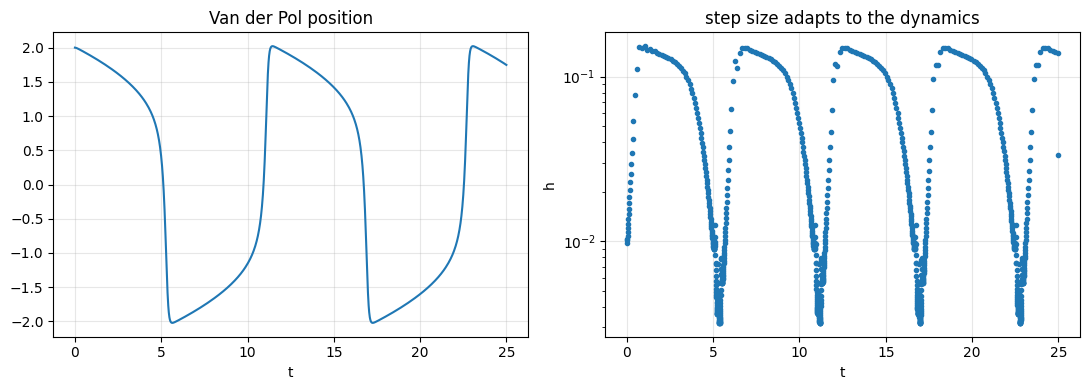

total steps taken: 882  (a fixed grid would need far more)


In [4]:
def rk23_adaptive(f, t0, y0, tf, tol=1e-6, h0=0.1):
    t, y, h = t0, np.array(y0, dtype=float), h0
    ts, ys, hs = [t], [y.copy()], []
    while t < tf:
        h = min(h, tf - t)
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2 * k1)
        k3 = f(t + 3*h/4, y + 3*h/4 * k2)
        y3 = y + h/9 * (2*k1 + 3*k2 + 4*k3)          # 3rd-order estimate
        k4 = f(t + h, y3)
        y2 = y + h/24 * (7*k1 + 6*k2 + 8*k3 + 3*k4)  # 2nd-order estimate
        err = np.linalg.norm(y3 - y2) + 1e-300
        if err <= tol:
            t += h; y = y3
            ts.append(t); ys.append(y.copy()); hs.append(h)
        h *= min(2.0, max(0.2, 0.9 * (tol/err)**(1/3)))   # PI-style adjustment
    return np.array(ts), np.array(ys), np.array(hs)

# Van der Pol oscillator: smooth then rapid, ideal for adaptivity.
mu = 5.0
vdp = lambda t, y: np.array([y[1], mu*(1 - y[0]**2)*y[1] - y[0]])
ts, ys, hs = rk23_adaptive(vdp, 0, [2.0, 0.0], 25.0, tol=1e-5)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(ts, ys[:, 0]); axs[0].set_title("Van der Pol position"); axs[0].set_xlabel("t")
axs[1].semilogy(ts[1:], hs, ".")
axs[1].set_title("step size adapts to the dynamics"); axs[1].set_xlabel("t"); axs[1].set_ylabel("h")
plt.tight_layout(); plt.show()
print("total steps taken:", len(hs), " (a fixed grid would need far more)")


Notice how the step size *collapses* during the sharp transitions and *grows* in the smooth phases — the integrator allocates effort intelligently. This is the single most important feature of production ODE solvers.

## 4. Stiffness and implicit methods

Some systems have wildly different time scales. For these **stiff** problems, an explicit method like RK4 must take absurdly tiny steps for **stability** (not accuracy) — otherwise it blows up. Consider $y' = -50y$, $y(0)=1$, whose true solution decays gently to $0$.


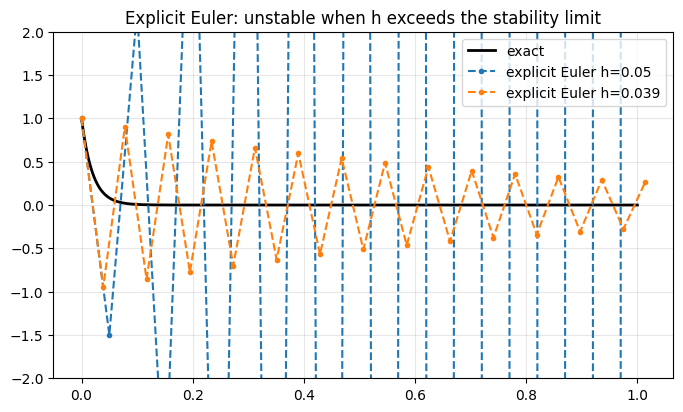

In [5]:
lam = -50.0
stiff = lambda t, y: lam * y
exact_stiff = lambda t: np.exp(lam * t)

# Explicit Euler is stable only if |1 + h*lam| < 1, i.e. h < 2/50 = 0.04.
fig, ax = plt.subplots()
tt = np.linspace(0, 1, 400)
ax.plot(tt, exact_stiff(tt), "k", lw=2, label="exact")
for h in [0.05, 0.039]:
    ts, ys = euler(stiff, 0, 1.0, 1.0, h)
    ax.plot(ts, ys, "o--", ms=3, label=f"explicit Euler h={h}")
ax.set_ylim(-2, 2)
ax.set_title("Explicit Euler: unstable when h exceeds the stability limit")
ax.legend(); plt.show()


For $h = 0.05$ the explicit method oscillates with growing amplitude — pure instability, even though the true solution is trivially smooth. The cure is **Backward (implicit) Euler**:

$$ y_{n+1} = y_n + h\, f(t_{n+1}, y_{n+1}), $$

which requires solving an equation for $y_{n+1}$ each step (here linear; in general a root-find — Week 2!). Backward Euler is **unconditionally stable**: any step size stays bounded.


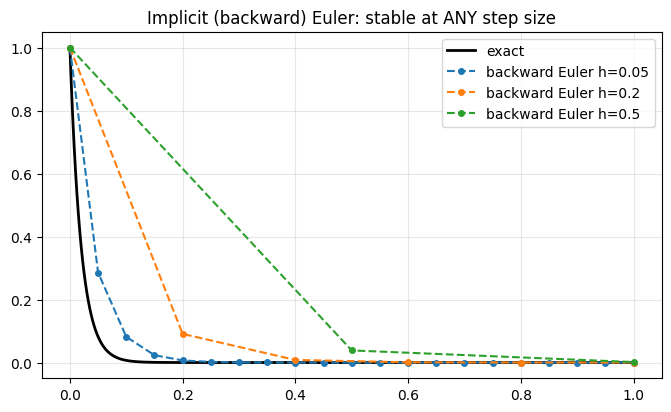

In [6]:
def backward_euler_linear(lam, t0, y0, tf, h):
    ts = np.arange(t0, tf + 0.5*h, h)
    ys = np.zeros(len(ts)); ys[0] = y0
    for n in range(len(ts)-1):
        ys[n+1] = ys[n] / (1 - h*lam)        # solve (1 - h*lam) y_{n+1} = y_n
    return ts, ys

fig, ax = plt.subplots()
ax.plot(tt, exact_stiff(tt), "k", lw=2, label="exact")
for h in [0.05, 0.2, 0.5]:
    ts, ys = backward_euler_linear(lam, 0, 1.0, 1.0, h)
    ax.plot(ts, ys, "o--", ms=4, label=f"backward Euler h={h}")
ax.set_title("Implicit (backward) Euler: stable at ANY step size")
ax.legend(); plt.show()


Even with a huge step, backward Euler stays well-behaved. Stiffness is *the* reason implicit solvers exist — a lesson that scales all the way up to industrial simulations.

## 5. Boundary-value problems via finite differences

So far we marched forward in time (initial-value problems). A **boundary-value problem** fixes values at *both* ends, e.g.

$$ -u''(x) = g(x), \quad x\in(0,1), \qquad u(0)=u(1)=0. $$

Discretize $u''$ with the central second difference on a grid of $N$ interior points, $u''(x_i)\approx \frac{u_{i-1}-2u_i+u_{i+1}}{h^2}$. The result is a **tridiagonal linear system** $A\mathbf{u} = \mathbf{g}$ — and we solve it with the very factorizations from Week 3. The whole course closes the loop here.


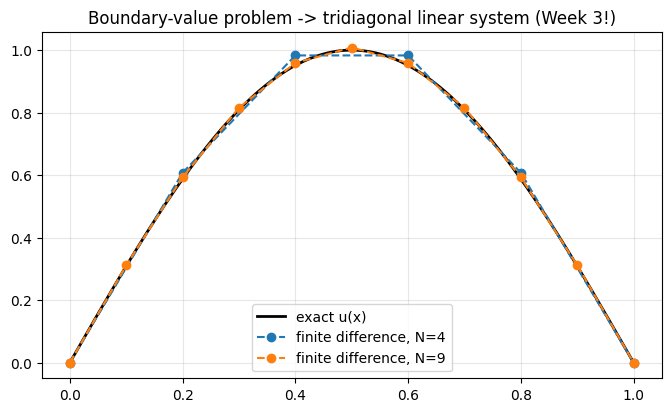

In [7]:
def solve_bvp_poisson(g, N):
    h = 1.0 / (N + 1)
    x = np.linspace(0, 1, N + 2)
    xi = x[1:-1]                                   # interior points
    # Build the (1/h^2) * tridiag(-1, 2, -1) operator for -u''.
    main = 2*np.ones(N); off = -1*np.ones(N-1)
    A = (np.diag(main) + np.diag(off, 1) + np.diag(off, -1)) / h**2
    b = g(xi)
    u_interior = np.linalg.solve(A, b)
    u = np.concatenate(([0.0], u_interior, [0.0]))
    return x, u

# Manufactured solution: u(x) = sin(pi x)  =>  -u'' = pi^2 sin(pi x).
g = lambda x: np.pi**2 * np.sin(np.pi * x)
u_exact = lambda x: np.sin(np.pi * x)

fig, ax = plt.subplots()
xf = np.linspace(0, 1, 400)
ax.plot(xf, u_exact(xf), "k", lw=2, label="exact u(x)")
for N in [4, 9]:
    x, u = solve_bvp_poisson(g, N)
    ax.plot(x, u, "o--", label=f"finite difference, N={N}")
ax.set_title("Boundary-value problem -> tridiagonal linear system (Week 3!)")
ax.legend(); plt.show()


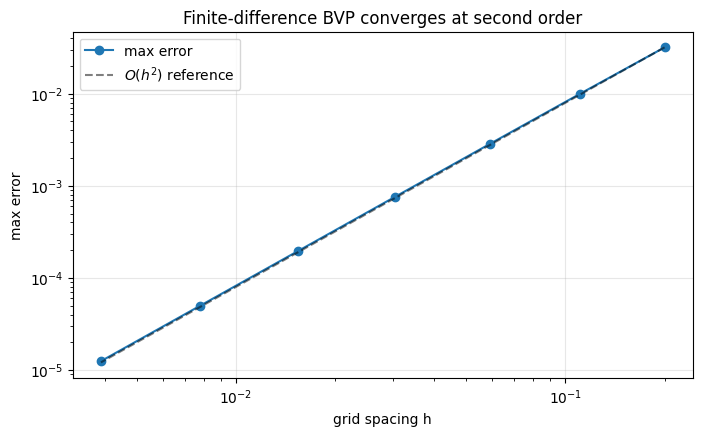

In [8]:
# Verify second-order convergence: error should scale like h^2.
Ns = [4, 8, 16, 32, 64, 128, 256]
errs, hs = [], []
for N in Ns:
    x, u = solve_bvp_poisson(g, N)
    errs.append(np.max(np.abs(u - u_exact(x))))
    hs.append(1.0/(N+1))

fig, ax = plt.subplots()
ax.loglog(hs, errs, "o-", label="max error")
ax.loglog(hs, np.array(hs)**2 * errs[0]/hs[0]**2, "k--", alpha=0.5, label=r"$O(h^2)$ reference")
ax.set_xlabel("grid spacing h"); ax.set_ylabel("max error")
ax.set_title("Finite-difference BVP converges at second order"); ax.legend(); plt.show()


## Course synthesis

This capstone wove together every thread of the course:

- **Error analysis (W1)** told us why step sizes have sweet spots and why stability matters.
- **Root-finding (W2)** lives inside every implicit ODE step.
- **Linear systems (W3)** solve the tridiagonal BVP discretization.
- **Interpolation (W4)** underlies Runge–Kutta's multi-stage slope sampling.
- **Quadrature (W5)** is the integral form behind every time-stepping scheme.

Numerical methods is not a bag of tricks — it is one coherent discipline about turning continuous mathematics into finite, stable, convergent computation.

---

## Exercises

**1. (Order verification.)** Empirically confirm RK4 is fourth order and Euler first order on the nonlinear problem $y' = -y^2$, $y(0)=1$ (exact $y=1/(1+t)$).

**2. (Symplectic integrators.)** For the harmonic oscillator, compare energy drift in explicit Euler, RK4, and the symplectic *leapfrog* method over long times. Explain why leapfrog conserves energy despite being only second order.

**3. (Stability regions.)** Plot the region of absolute stability in the complex $h\lambda$-plane for explicit Euler and RK4. Relate it to the stiff blow-up you observed.

**4. (Implicit nonlinear.)** Implement backward Euler for a *nonlinear* stiff ODE, using your Week-2 Newton solver to solve the per-step equation. Verify unconditional stability.

**5. (Variable-coefficient BVP.)** Extend the finite-difference solver to $-(a(x)u')' = g(x)$ with non-constant $a(x)$, keeping the matrix tridiagonal. Confirm second-order convergence on a manufactured solution.

**6. (2D Poisson.)** Generalize the BVP solver to $-\nabla^2 u = g$ on the unit square with the 5-point stencil. Solve the resulting sparse system and visualize with `plt.imshow`.
